In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [ ]:

df = pd.read_csv('/content/gwalior_food_dataset_330_unique.csv')
display(df.head())

,id,restaurant,dish,cuisine,price,rating,city,area,dietary,spicy,mood_tags,meal_type,distance_km,delivery_minutes,image_url
0,1,Tandoori House,Paneer Tikka,North Indian,240,3.8,Gwalior,City Centre,Vegetarian,True,"comfort, happy, social","lunch, dinner",3.1,25,"https://loremflickr.com/800/600/paneer,tikka?l..."
1,2,The Spice Route,Butter Chicken,North Indian,280,4.5,Gwalior,Lashkar,Non-Vegetarian,True,"comfort, happy, tired","lunch, dinner",3.9,36,"https://loremflickr.com/800/600/butter,chicken..."
2,3,Gwalior Zaika,Vada Sambar,South Indian,80,4.3,Gwalior,Thatipur,Vegetarian,True,"happy, comfort","breakfast, snacks",2.1,21,"https://loremflickr.com/800/600/vada,sambar?lo..."
3,4,Royal Rasoi,Farmhouse Pizza,Italian,280,4.3,Gwalior,Morar,Vegetarian,False,"happy, social, adventurous","lunch, dinner",3.1,25,"https://loremflickr.com/800/600/farmhouse,pizz..."
4,5,Swaad Junction,Special Thali,North Indian,280,4.5,Gwalior,Mahalgaon,Vegetarian,True,"comfort, happy, social","lunch, dinner",4.2,31,"https://loremflickr.com/800/600/special,thali?..."


In [ ]:

print(df.shape)

(330, 15)


In [ ]:
df.info()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                330 non-null    int64  
 1   restaurant        330 non-null    object 
 2   dish              330 non-null    object 
 3   cuisine           330 non-null    object 
 4   price             330 non-null    int64  
 5   rating            330 non-null    float64
 6   city              330 non-null    object 
 7   area              330 non-null    object 
 8   dietary           330 non-null    object 
 9   spicy             330 non-null    bool   
 10  mood_tags         330 non-null    object 
 11  meal_type         330 non-null    object 
 12  distance_km       330 non-null    float64
 13  delivery_minutes  330 non-null    int64  
 14  image_url         330 non-null    object 
dtypes: bool(1), float64(2), int64(3), object(9)
memory usage: 36.5+ KB


np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
restaurant,0
dish,0
cuisine,0
price,0
rating,0
city,0
area,0
dietary,0
spicy,0


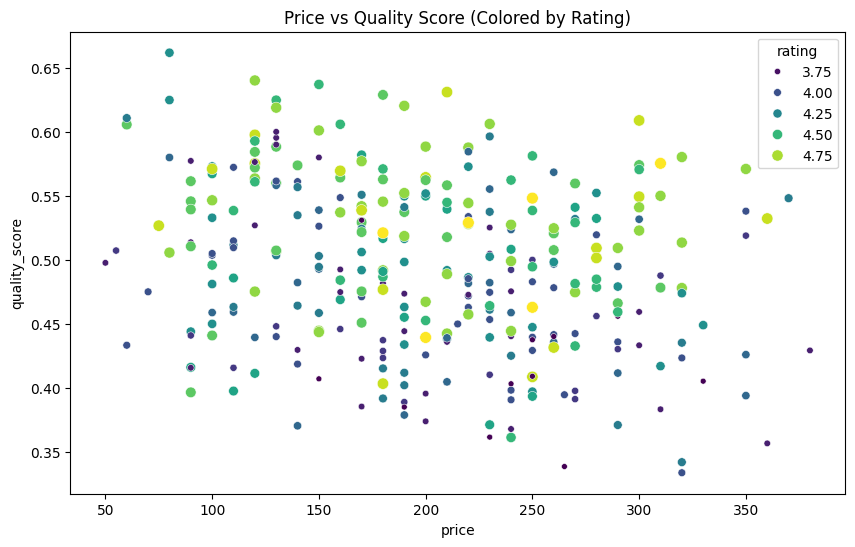

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='quality_score', hue='rating', palette='viridis', size='rating')
plt.title('Price vs Quality Score (Colored by Rating)')
plt.show()

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
import joblib

df = pd.read_csv('gwalior_food_dataset_330_unique.csv')

# 1. Combine descriptive attributes into a rich semantic metadata string
def create_soup(row):
    moods = " ".join([m.strip().lower() for m in str(row['mood_tags']).split(',')])
    meals = " ".join([m.strip().lower() for m in str(row['meal_type']).split(',')])
    diet = str(row['dietary']).lower()
    cuisine = str(row['cuisine']).lower()
    spicy = "spicy" if row['spicy'] else "mild"
    area = str(row['area']).lower()
    return f"{cuisine} {diet} {spicy} {moods} {meals} {area}"

df['content_soup'] = df.apply(create_soup, axis=1)

# 2. Build TF-IDF Feature Matrix for content-based matching
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['content_soup'])

# 3. Scaled Quality Prior (Rating & Delivery speed)
scaler = MinMaxScaler()
df['norm_rating'] = scaler.fit_transform(df[['rating']])
df['norm_delivery'] = 1.0 - scaler.fit_transform(df[['delivery_minutes']])
df['base_quality'] = (0.6 * df['norm_rating']) + (0.4 * df['norm_delivery'])

# 4. Recommendation Function with Similarity, Mood, and History Boost
def recommend(mood, budget, location, dietary, spicy=None, user_liked_ids=[], top_n=5):
    # Hard constraint: Filter budget and dietary restrictions
    candidates = df[df['price'] <= budget].copy()
    if dietary:
        candidates = candidates[candidates['dietary'].str.lower() == dietary.lower()]
    if spicy is not None:
        candidates = candidates[candidates['spicy'] == spicy]

    if candidates.empty:
        return []

    # Construct user query vector
    user_query = f"{dietary.lower()} {mood.lower()} {location.lower()}"
    query_vec = tfidf.transform([user_query])

    # Calculate Content Similarity
    cand_indices = candidates.index
    sim_scores = cosine_similarity(query_vec, tfidf_matrix[cand_indices]).flatten()
    candidates['sim_score'] = sim_scores

    # Personalization: Boost items from cuisines or restaurants previously liked
    if user_liked_ids:
        liked_items = df[df['id'].isin(user_liked_ids)]
        liked_cuisines = set(liked_items['cuisine'].str.lower())
        candidates['personal_boost'] = candidates['cuisine'].str.lower().apply(
            lambda c: 0.15 if c in liked_cuisines else 0.0
        )
    else:
        candidates['personal_boost'] = 0.0

    # Final Combined Ranking Score (0.0 to 1.0 scale)
    candidates['final_score'] = (
        (candidates['sim_score'] * 0.50) +
        (candidates['base_quality'] * 0.35) +
        candidates['personal_boost']
    )

    # Sort and pick top N
    results = candidates.sort_values('final_score', ascending=False).head(top_n)

    # Generate explanation reasons (Mandatory in assignment)
    recs = []
    for _, row in results.iterrows():
        reasons = []
        if mood.lower() in str(row['mood_tags']).lower():
            reasons.append(f"matches your {mood} mood")
        if row['price'] <= budget * 0.8:
            reasons.append("well within budget")
        if row['rating'] >= 4.3:
            reasons.append(f"highly rated ({row['rating']}★)")

        reason_str = f"Recommended because it {' and '.join(reasons)}." if reasons else "Top match for your preferences."

        recs.append({
            "id": int(row['id']),
            "dish": row['dish'],
            "restaurant": row['restaurant'],
            "price": row['price'],
            "rating": row['rating'],
            "match_percent": int(row['final_score'] * 100),
            "reason": reason_str
        })
    return recs